In [1]:
using ITensors, ITensorMPS
using ITransverse
using Plots
using Plots.PlotMeasures
using ProgressMeter
ProgressMeter.ijulia_behavior(:clear)

using Revise

includet("Alcaraz_2ndOrder_MPOgenerator.jl")

struct AlcarazModel <: ModelParams
    lambda::Float64
    p::Float64
    phys_site::Index
end

Hamiltonian given by:
$$H = -\sum_i \left( \sigma_i^z \sigma_{i+1}^z + \lambda \sigma_i^x \mathbf{+} p \sigma_i^z \sigma_{i+2}^z + p \lambda \sigma_i^x \sigma_{i+1}^x \right)$$

In [2]:
# System Parameters

# Alcaraz's NNN Self Dual Critical model
N = 50        
lambda = 1.0    # exact critical point (self dual)
p = 0.5         # NNN term (p>0 breakes system's integrability)

# Physical indices
sites = siteinds("S=1/2", N)

50-element Vector{Index{Int64}}:
 (dim=2|id=136|"S=1/2,Site,n=1")
 (dim=2|id=356|"S=1/2,Site,n=2")
 (dim=2|id=644|"S=1/2,Site,n=3")
 (dim=2|id=421|"S=1/2,Site,n=4")
 (dim=2|id=361|"S=1/2,Site,n=5")
 (dim=2|id=386|"S=1/2,Site,n=6")
 (dim=2|id=623|"S=1/2,Site,n=7")
 (dim=2|id=494|"S=1/2,Site,n=8")
 (dim=2|id=427|"S=1/2,Site,n=9")
 (dim=2|id=618|"S=1/2,Site,n=10")
 (dim=2|id=802|"S=1/2,Site,n=11")
 (dim=2|id=770|"S=1/2,Site,n=12")
 (dim=2|id=317|"S=1/2,Site,n=13")
 ⋮
 (dim=2|id=122|"S=1/2,Site,n=39")
 (dim=2|id=171|"S=1/2,Site,n=40")
 (dim=2|id=993|"S=1/2,Site,n=41")
 (dim=2|id=893|"S=1/2,Site,n=42")
 (dim=2|id=489|"S=1/2,Site,n=43")
 (dim=2|id=391|"S=1/2,Site,n=44")
 (dim=2|id=807|"S=1/2,Site,n=45")
 (dim=2|id=669|"S=1/2,Site,n=46")
 (dim=2|id=884|"S=1/2,Site,n=47")
 (dim=2|id=13|"S=1/2,Site,n=48")
 (dim=2|id=822|"S=1/2,Site,n=49")
 (dim=2|id=421|"S=1/2,Site,n=50")

In [3]:
using JLD2

# Load TVDP results for benchmarking

@load "tvdp_run.jld2" times_tdvp z_tdvp

2-element Vector{Symbol}:
 :times_tdvp
 :z_tdvp

### **The Higher-Order MPO Construction for Time Evolution**

To simulate the real-time dynamics of the Alcaraz model, we need a Matrix Product Operator (MPO) that approximates the time-evolution operator $U(dt) = e^{-i H dt}$. This is challenging because the Alcaraz Hamiltonian contains next-nearest-neighbor (NNN) interactions (e.g., $\sigma_i^z \sigma_{i+2}^z$). Standard Suzuki-Trotter decompositions struggle with NNN terms, often requiring cumbersome SWAP gates that artificially inflate entanglement. 

To overcome this, we use a higher-order finite-state machine construction:

**1. The Zaletel $W_{II}$ Foundation:** Instead of Trotterizing space, the Zaletel $W_{II}$ construction builds an MPO that acts as a "finite-state machine" reading from left to right. It allows the MPO to "memorize" a spin state at site $i$, carry that memory across site $i+1$, and interact it with site $i+2$. The standard $W_{II}$ formulation requires an internal bond dimension of $\chi_{W} = 4$ for this model but suffers from $O(dt^2)$ Trotter errors.

**2. The Optimal 2nd-Order Extension (Van Damme et al., 2023):**
To eliminate the "Trotter leak" (energy drift) over long simulation times, we utilize the "Optimal 2nd-Order MPO". This method is a higher-order generalization of the $W_{II}$ operator. By expanding the internal MPO bond dimension from $4$ to $13$, this mathematically advanced construction explicitly absorbs the disconnected clusters and overlapping cross-terms at higher orders. It correctly captures the Taylor expansion of $e^{-i H dt}$ up to $O(dt^2)$, while also intelligently compressing terms up to $O(dt^3)$. 

---

### Explicit Mathematical Expressions

Let $\tau = -i dt$. The local Hamiltonian terms are partitioned into the standard MPO generator blocks: $I, A, B, C, D$. 

The notation $\{X Y Z\}$ denotes the symmetric sum over all unique permutations of the operators (e.g., $\{A B\} = A B + B A$, and $\{A B C\} = A B C + A C B + B A C + B C A + C A B + C B A$). Note that multiplication between blocks involves a standard matrix product on the physical legs and a Kronecker (tensor) product on the virtual legs.

The Optimal 2nd-Order MPO is defined by the following $3 \times 3$ block matrix of operators:

**Row 1:**
$$W_{1,1} = \mathbb{I} + \tau D + \frac{\tau^2}{2} D^2 + \frac{\tau^3}{6} D^3$$
$$W_{1,2} = C + \frac{\tau}{2} \{C D\} + \frac{\tau^2}{6} \{C D D\}$$
$$W_{1,3} = C C + \frac{\tau}{3} \{C C D\}$$

**Row 2:**
$$W_{2,1} = \tau B + \frac{\tau^2}{2} \{B D\} + \frac{\tau^3}{6} \{B D D\}$$
$$W_{2,2} = A + \frac{\tau}{2} (\{B C\} + \{A D\}) + \frac{\tau^2}{6} (\{C B D\} + \{A D D\})$$
$$W_{2,3} = \{A C\} + \frac{\tau}{3} (\{A C D\} + \{C C B\})$$

**Row 3:**
$$W_{3,1} = \frac{\tau^2}{2} B B + \frac{\tau^3}{6} \{B B D\}$$
$$W_{3,2} = \frac{\tau}{2} \{A B\} + \frac{\tau^2}{6} (\{A B D\} + \{B B C\})$$
$$W_{3,3} = A A + \frac{\tau}{3} (\{A B C\} + \{A A D\})$$

Progress: 100%|█████████████████████████████████████████| Time: 0:00:17


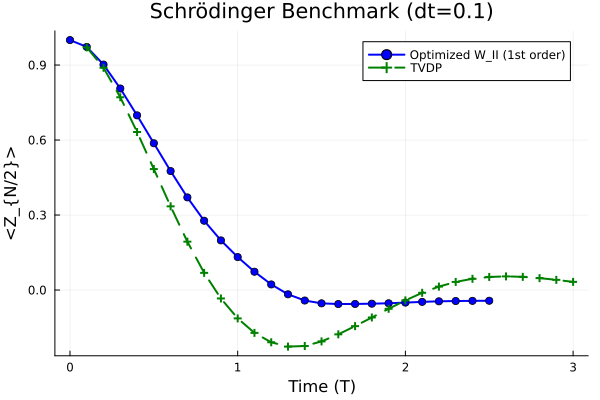

In [17]:
# SCHRÖDINGER TIME EVOLUTION
dt = 0.1
T_max = 2.5
cutoff = 1e-10
maxdim = 200
    
sites = siteinds("S=1/2", N)
psi = MPS(sites, "Up")
center_site = div(N, 2)
   
times = 0.0:dt:T_max
z_vals = Float64[]
push!(z_vals, real(expect(psi, "Z")[center_site]))
    
U_dt = expH_alcaraz_1st_opt(sites, lambda, p, dt=dt)
    
@showprogress for t in times[2:end]
    psi = apply(U_dt, psi; cutoff=1e-12, maxdim=400)
    normalize!(psi)
        
    val = real(expect(psi, "Z")[center_site])
    push!(z_vals, val)
end
    
p1 = plot(times, z_vals, 
    label="Optimized W_II (1st order)", 
    xlabel="Time (T)", ylabel="<Z_{N/2}>",
    lw=2, marker=:circle, color=:blue,
    title="Schrödinger Benchmark (dt=$dt)")

plot!(p1, times_tdvp, z_tdvp, 
    label="TVDP", 
    lw=2, color=:green, marker=:cross, ls=:dash)

display(p1)

Progress: 100%|█████████████████████████████████████████| Time: 0:02:26


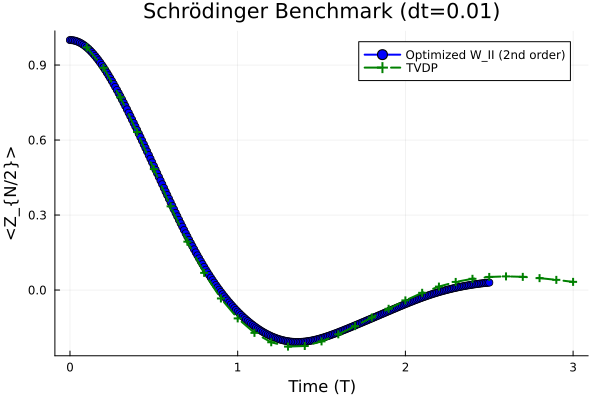

In [19]:
# SCHRÖDINGER TIME EVOLUTION (1st order)
dt = 0.01
T_max = 2.5
cutoff = 1e-10
maxdim = 200
    
sites = siteinds("S=1/2", N)
psi = MPS(sites, "Up")
center_site = div(N, 2)
   
times = 0.0:dt:T_max
z_vals = Float64[]
push!(z_vals, real(expect(psi, "Z")[center_site]))
    
U_dt = expH_alcaraz_1st_opt(sites, lambda, p, dt=dt)
    
@showprogress for t in times[2:end]
    psi = apply(U_dt, psi; cutoff=1e-12, maxdim=400)
    normalize!(psi)
        
    val = real(expect(psi, "Z")[center_site])
    push!(z_vals, val)
end
    
p1 = plot(times, z_vals, 
    label="Optimized W_II (2nd order)", 
    xlabel="Time (T)", ylabel="<Z_{N/2}>",
    lw=2, marker=:circle, color=:blue,
    title="Schrödinger Benchmark (dt=$dt)")

plot!(p1, times_tdvp, z_tdvp, 
    label="TVDP", 
    lw=2, color=:green, marker=:cross, ls=:dash)
    
display(p1)

## Light Cone Evolution & Entropy

In [4]:
mpo_generator = expH_alcaraz_2nd_opt
T_max = 2.5
dt = 0.1

# Setup Physical System
s = Index(2, "S=1/2")
init_state = up_state

# Package parameters + Folded Blocks
mp_alcaraz = AlcarazModel(lambda, p, s)
tp = tMPOParams(dt, mpo_generator, mp_alcaraz, 0, init_state)

# FoldtMPOBlocks extracts the translationally invariant tensor
fb = FoldtMPOBlocks(tp)

# fb.WWc

[ Info: Building WW tensors using expH_alcaraz_2nd_opt, build_imag=false, parameters AlcarazModel(1.0, 0.5, (dim=2|id=938|"S=1/2"))
┌ Warning: MPO tensor *not* symmetric in physical(space)  [=bond(time)] indices
└ @ ITransverse ~/.julia/packages/ITransverse/HS6vK/src/tmpo/fold_tmpo_blocks.jl:50
┌ Warning: MPO tensor *not* symmetric in bond(space) [=phys(time)] indices
└ @ ITransverse ~/.julia/packages/ITransverse/HS6vK/src/tmpo/fold_tmpo_blocks.jl:56
[ Info: Building WW tensors using expH_alcaraz_2nd_opt, build_imag=true, parameters AlcarazModel(1.0, 0.5, (dim=2|id=938|"S=1/2"))


[[*Folded*]] tMPO Blocks, type Vector{ComplexF64}
tMPOParams:   dt: 0.1 | dbeta: 0.0 - 0.1im  || nbeta : 0
exp(H) func:  expH_alcaraz_2nd_opt  |  Model params: AlcarazModel(1.0, 0.5, (dim=2|id=938|"S=1/2"))
Init state:   ComplexF64[1.0 + 0.0im, 0.0 + 0.0im]



In [ ]:
function run_light_cone_evol(
    mpo_generator; T_max::Float64 = 2.5, dt::Float64 = 0.1, lambda::Float64 = 1.0, p::Float64 = 0.5, init_state = up_state,
    cutoff::Float64 = 1e-12, maxdim::Int = 256,
    times_tdvp = nothing, z_tdvp = nothing)

    s = Index(2, "S=1/2")
    mp_alcaraz = AlcarazModel(lambda, p, s)
    tp = tMPOParams(dt, 0.0im, mpo_generator, mp_alcaraz, 0, init_state)
    fb = FoldtMPOBlocks(tp)
    
    # Light Cone Parameters
    trunc_params = (; cutoff=cutoff, maxdim=maxdim, direction=:left, alg=:naiveRTM)
    
    cp = ConeParams(;
        truncp = trunc_params,
        opt_method = :nosym,
        vwidth = 1    
    )
    
    # Initialize the cone
    init_mps = init_cone(fb, 1)
    
    # Pre-calculate final steps for the checkpoint
    Nt_final = Int(round(T_max / dt))

    # Observables
    chk = DoCheckpoint(
        "cp_alcaraz_dynamics_L$(lambda)_p$(p).jld2";
        params = Dict("tparams" => tp, "cparams" => cp),
        save_at = [Nt_final],
        f_obs = (
            temp_entropy = s -> vn_entanglement_entropy(s.R), 
            
            Z_normed = s -> real(
                first(compute_expvals(s.L, s.R, ["Z"], s.b)["Z"]) / 
                first(compute_expvals(s.L, s.R, ["Id"], s.b)["Id"])
            )
        ),
        f_savestate = (
                L = s -> s.L,
                R = s -> s.R,
                b = s -> s.b
            )
    )
    
    # Run Simulation
    L_final, R_final, checkpt = run_cone(init_mps, fb, cp, chk, Nt_final)
    
    # Extract Data
    svn_vals_raw = checkpt.obs_hist[:temp_entropy]
    svn_max = [maximum(real(v)) for v in svn_vals_raw]     
    z_vals = checkpt.obs_hist[:Z_normed]
    
    times_plot = [n * dt for n in 1:length(svn_max)]
    
    # Plotting
    p1 = plot(times_plot, svn_max, 
            label="Max Transverse SvN (p=$p)", 
            xlabel="Time", 
            ylabel="Temporal Entanglement", 
            lw=2, color=:red, marker=:circle,
            title="Simulation Complexity")
    
    p2 = plot(times_plot, z_vals, 
            label="Light cone (dt=$dt)", 
            xlabel="Time", 
            ylabel="<Z_{N/2}>", 
            lw=2, color=:green, marker=:circle,
            title="Alcaraz Quench Dynamics")
    
    if !isnothing(times_tdvp) && !isnothing(z_tdvp)
        plot!(p2, times_tdvp, z_tdvp, 
            label="TDVP Benchmark", 
            lw=2, color=:blue, marker=:cross, ls=:dash)
    end
    
    p_final = plot(p1, p2, layout=(1, 2), size=(1000, 400), bottom_margin=5mm, left_margin=5mm)
    display(p_final)
    
end

run_light_cone_evol (generic function with 1 method)

[cone(v=1)|nosym|naiveRTM] [ψ0=>Op] cutoff=1.0e-12, maxdim=256) 100% Time: 1:03:05 (15.20  s/it)
   Info: [250] χ=58, (L|R) = 1.1543225404491189 + 2.3878949822422205e-15im 
[ Info: Saving CP OUTcone_final.jld2...


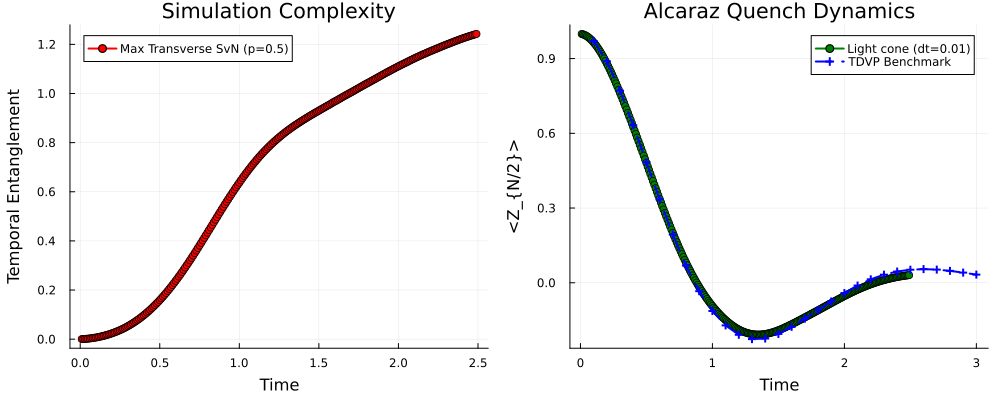

(L_final = MPS(250), R_final = MPS(250), checkpt = DoCheckpoint{Dict{String, Any}, @NamedTuple{temp_entropy::var"#59#60", Z_normed::var"#61#62"}, @NamedTuple{L::var"#63#64", R::var"#65#66", b::var"#67#68"}, Vector{Int64}}("cp_alcaraz_dynamics_L1.0_p0.5.jld2", [250], Dict{String, Any}("cparams" => ConeParams{Int64, @NamedTuple{cutoff::Float64, maxdim::Int64, direction::Symbol, alg::Symbol}}((cutoff = 1.0e-12, maxdim = 256, direction = :left, alg = :naiveRTM), :nosym, [1, 0, 0, 1], 1), "tparams" => tMPOParams:   dt: 0.01 | dbeta: 0.0 + 0.0im  || nbeta : 0
exp(H) func:  expH_alcaraz_WII  |  Model params: AlcarazModel(1.0, 0.5, (dim=2|id=307|"S=1/2"))
Init state:   ComplexF64[1.0 + 0.0im, 0.0 + 0.0im]
), [2, 3, 4, 5, 6, 7, 8, 9, 10, 11  …  241, 242, 243, 244, 245, 246, 247, 248, 249, 250], (temp_entropy = var"#59#60"(), Z_normed = var"#61#62"()), Dict{Symbol, Vector}(:temp_entropy => [[0.00029204363263109787], [0.000544317708280707, 0.0005646110534112227], [0.000779251048983607, 0.00104826

In [ ]:
mpo_generator = expH_alcaraz_WII # not optimised version

results = run_light_cone_evol(
    mpo_generator;
    dt = 0.01,
    p = 0.5,
    times_tdvp = times_tdvp,
    z_tdvp = z_tdvp
)

[cone(v=1)|nosym|naiveRTM] [ψ0=>Op] cutoff=1.0e-12, maxdim=256) 100% Time: 0:11:42 ( 2.82  s/it)
   Info: [250] χ=18, (L|R) = 1.15451380657754 + 1.2136584667673014e-9im 
[ Info: Saving CP OUTcone_final.jld2...


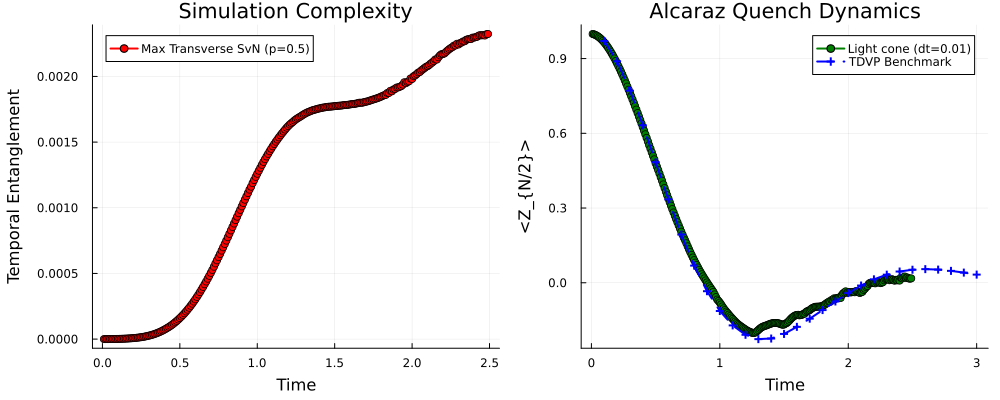

(L_final = MPS(250), R_final = MPS(250), checkpt = DoCheckpoint{Dict{String, Any}, @NamedTuple{temp_entropy::var"#59#60", Z_normed::var"#61#62"}, @NamedTuple{L::var"#63#64", R::var"#65#66", b::var"#67#68"}, Vector{Int64}}("cp_alcaraz_dynamics_L1.0_p0.5.jld2", [250], Dict{String, Any}("cparams" => ConeParams{Int64, @NamedTuple{cutoff::Float64, maxdim::Int64, direction::Symbol, alg::Symbol}}((cutoff = 1.0e-12, maxdim = 256, direction = :left, alg = :naiveRTM), :nosym, [1, 0, 0, 1], 1), "tparams" => tMPOParams:   dt: 0.01 | dbeta: 0.0 + 0.0im  || nbeta : 0
exp(H) func:  expH_alcaraz_1st_opt  |  Model params: AlcarazModel(1.0, 0.5, (dim=2|id=794|"S=1/2"))
Init state:   ComplexF64[1.0 + 0.0im, 0.0 + 0.0im]
), [2, 3, 4, 5, 6, 7, 8, 9, 10, 11  …  241, 242, 243, 244, 245, 246, 247, 248, 249, 250], (temp_entropy = var"#59#60"(), Z_normed = var"#61#62"()), Dict{Symbol, Vector}(:temp_entropy => [[5.2340245559674366e-8], [1.0163507450774551e-7, 1.0234960396468892e-7], [1.5024243471259674e-7, 1.989

In [11]:
mpo_generator = expH_alcaraz_1st_opt

results = run_light_cone_evol(
    mpo_generator;
    dt = 0.01,
    p = 0.5,
    times_tdvp = times_tdvp,
    z_tdvp = z_tdvp
)

[cone(v=1)|nosym|naiveRTM] [ψ0=>Op] cutoff=1.0e-12, maxdim=256) 100% Time: 0:40:05 (19.40  s/it)
   Info: [125] χ=24, (L|R) = 1.0000154806319876 + 7.459941986245975e-16im 
[ Info: Saving CP OUTcone_final.jld2...


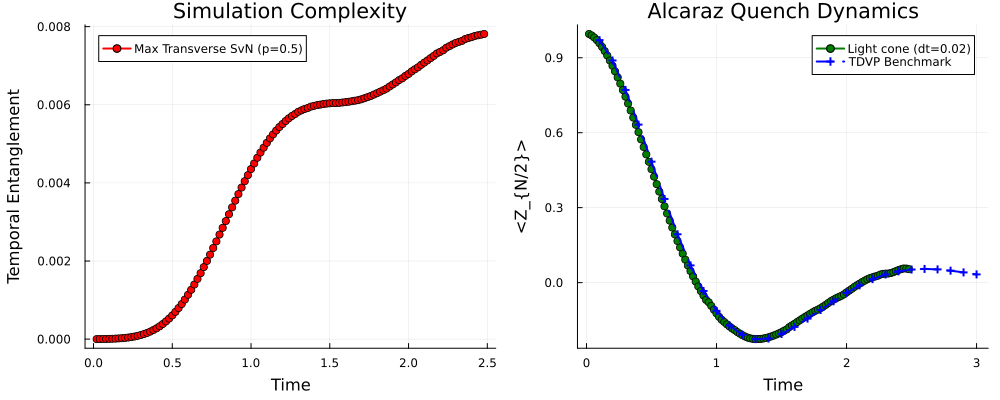

(L_final = MPS(125), R_final = MPS(125), checkpt = DoCheckpoint{Dict{String, Any}, @NamedTuple{temp_entropy::var"#38#39", Z_normed::var"#40#41"}, @NamedTuple{L::var"#42#43", R::var"#44#45", b::var"#46#47"}, Vector{Int64}}("cp_alcaraz_dynamics_L1.0_p0.5.jld2", [125], Dict{String, Any}("cparams" => ConeParams{Int64, @NamedTuple{cutoff::Float64, maxdim::Int64, direction::Symbol, alg::Symbol}}((cutoff = 1.0e-12, maxdim = 256, direction = :left, alg = :naiveRTM), :nosym, [1, 0, 0, 1], 1), "tparams" => tMPOParams:   dt: 0.02 | dbeta: 0.0 + 0.0im  || nbeta : 0
exp(H) func:  expH_alcaraz_2nd_opt  |  Model params: AlcarazModel(1.0, 0.5, (dim=2|id=543|"S=1/2"))
Init state:   ComplexF64[1.0 + 0.0im, 0.0 + 0.0im]
), [2, 3, 4, 5, 6, 7, 8, 9, 10, 11  …  116, 117, 118, 119, 120, 121, 122, 123, 124, 125], (temp_entropy = var"#38#39"(), Z_normed = var"#40#41"()), Dict{Symbol, Vector}(:temp_entropy => [[7.388074604449116e-7], [1.4451794744723981e-6, 1.4833962842421345e-6], [2.163757040073138e-6, 2.91761

In [5]:
mpo_generator = expH_alcaraz_2nd_opt

results = run_light_cone_evol(
    mpo_generator;
    dt = 0.02,
    T_max = 2.5,
    p = 0.5,
    times_tdvp = times_tdvp,
    z_tdvp = z_tdvp
)

[cone(v=1)|nosym|naiveRTM] [ψ0=>Op] cutoff=1.0e-12, maxdim=256) 100% Time: 0:12:40 (15.51  s/it)
   Info: [50] χ=37, (L|R) = 1.0002580992577643 + 1.777031077626265e-15im 
[ Info: Saving CP OUTcone_final.jld2...


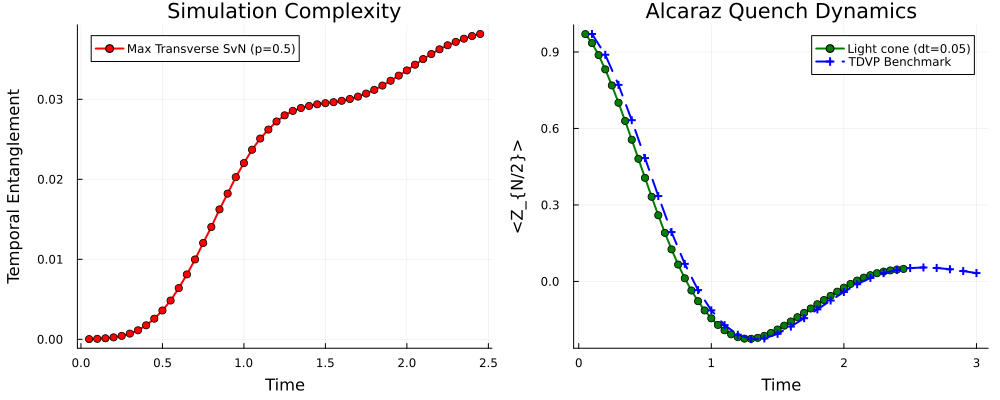

(L_final = MPS(50), R_final = MPS(50), checkpt = DoCheckpoint{Dict{String, Any}, @NamedTuple{temp_entropy::var"#38#39", Z_normed::var"#40#41"}, @NamedTuple{L::var"#42#43", R::var"#44#45", b::var"#46#47"}, Vector{Int64}}("cp_alcaraz_dynamics_L1.0_p0.5.jld2", [50], Dict{String, Any}("cparams" => ConeParams{Int64, @NamedTuple{cutoff::Float64, maxdim::Int64, direction::Symbol, alg::Symbol}}((cutoff = 1.0e-12, maxdim = 256, direction = :left, alg = :naiveRTM), :nosym, [1, 0, 0, 1], 1), "tparams" => tMPOParams:   dt: 0.05 | dbeta: 0.0 + 0.0im  || nbeta : 0
exp(H) func:  expH_alcaraz_2nd_opt  |  Model params: AlcarazModel(1.0, 0.5, (dim=2|id=814|"S=1/2"))
Init state:   ComplexF64[1.0 + 0.0im, 0.0 + 0.0im]
), [2, 3, 4, 5, 6, 7, 8, 9, 10, 11  …  41, 42, 43, 44, 45, 46, 47, 48, 49, 50], (temp_entropy = var"#38#39"(), Z_normed = var"#40#41"()), Dict{Symbol, Vector}(:temp_entropy => [[2.56069445729954e-5], [5.27167967656741e-5, 6.030561172787981e-5], [8.376791794603783e-5, 0.0001260151477050511, 0

In [5]:
mpo_generator = expH_alcaraz_2nd_opt

results = run_light_cone_evol(
    mpo_generator;
    dt = 0.05,
    T_max = 2.5,
    p = 0.5,
    times_tdvp = times_tdvp,
    z_tdvp = z_tdvp
)

[cone(v=1)|nosym|naiveRTM] [ψ0=>Op] cutoff=1.0e-12, maxdim=256) 100% Time: 0:12:09 (25.17  s/it)
   Info: [30] χ=64, (L|R) = 1.0034122385748439 - 9.541521218958682e-16im 
[ Info: Saving CP OUTcone_final.jld2...


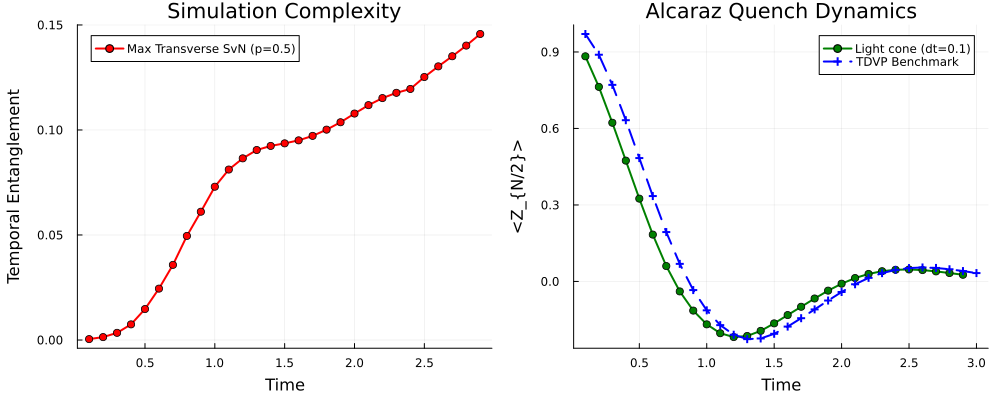

(L_final = MPS(30), R_final = MPS(30), checkpt = DoCheckpoint{Dict{String, Any}, @NamedTuple{temp_entropy::var"#38#39", Z_normed::var"#40#41"}, @NamedTuple{L::var"#42#43", R::var"#44#45", b::var"#46#47"}, Vector{Int64}}("cp_alcaraz_dynamics_L1.0_p0.5.jld2", [30], Dict{String, Any}("cparams" => ConeParams{Int64, @NamedTuple{cutoff::Float64, maxdim::Int64, direction::Symbol, alg::Symbol}}((cutoff = 1.0e-12, maxdim = 256, direction = :left, alg = :naiveRTM), :nosym, [1, 0, 0, 1], 1), "tparams" => tMPOParams:   dt: 0.1 | dbeta: 0.0 + 0.0im  || nbeta : 0
exp(H) func:  expH_alcaraz_2nd_opt  |  Model params: AlcarazModel(1.0, 0.5, (dim=2|id=606|"S=1/2"))
Init state:   ComplexF64[1.0 + 0.0im, 0.0 + 0.0im]
), [2, 3, 4, 5, 6, 7, 8, 9, 10, 11  …  21, 22, 23, 24, 25, 26, 27, 28, 29, 30], (temp_entropy = var"#38#39"(), Z_normed = var"#40#41"()), Dict{Symbol, Vector}(:temp_entropy => [[0.000435220193637762], [0.0009599479301473048, 0.0013925340685393987], [0.0015919440683049163, 0.0030640287358214, 

In [6]:
mpo_generator = expH_alcaraz_2nd_opt

results = run_light_cone_evol(
    mpo_generator;
    dt = 0.1,
    T_max = 3.0,
    p = 0.5,
    times_tdvp = times_tdvp,
    z_tdvp = z_tdvp
)

it seems there is a fine balance between the trotter error we make when making dt smaller, and the error that is made by the package for having a really long temporal chain... we have to find the sweet spot every time we want to compute something.